CATEGORY 5 COMPUTATION - IRIS DATASET

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler


In [2]:
# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
target_names = iris.target_names

In [3]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
 #Standardize the features (Important for LDA as it uses covariance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Create an LDA model for classification
lda_clf = LinearDiscriminantAnalysis()
lda_clf.fit(X_train_scaled, y_train)


LinearDiscriminantAnalysis()

In [6]:
# Use LDA for dimensionality reduction (to 2D for plotting)
lda_for_plot = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda_for_plot.fit_transform(X_train_scaled, y_train)

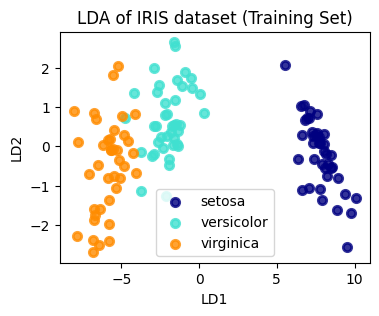

In [7]:
# Plot the transformed training data
plt.figure(figsize=(4, 3))
colors = ['navy', 'turquoise', 'darkorange']
lw = 2

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_train_lda[y_train == i, 0],
                X_train_lda[y_train == i, 1],
                color=color, alpha=.8, lw=lw, label=target_name)
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.title('LDA of IRIS dataset (Training Set)')
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.show()

In [8]:
# Predict on the test set
y_pred = lda_clf.predict(X_test_scaled)


In [9]:
# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 1.00


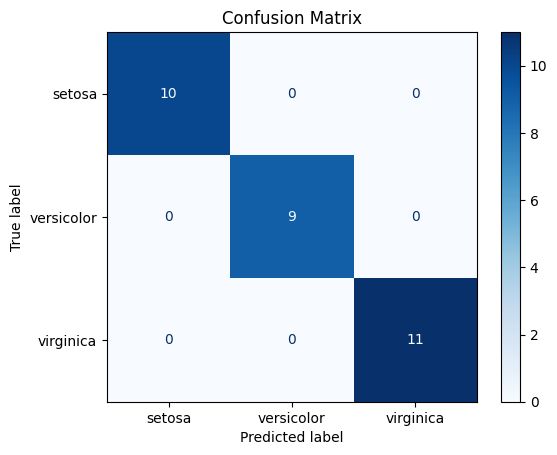

In [10]:
# Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [11]:
# Using LDA with shrinkage for potential regularization
lda_shrink = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda_shrink.fit(X_train_scaled, y_train)
y_pred_shrink = lda_shrink.predict(X_test_scaled)
accuracy_shrink = accuracy_score(y_test, y_pred_shrink)
print(f"Test Accuracy with Shrinkage: {accuracy_shrink:.2f}")

Test Accuracy with Shrinkage: 1.00


Category 5 - Illustration

In [12]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler


In [13]:
# Load Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names


In [14]:
# For illustration, use only two features: Petal length and Petal width
X_2d = X[:, 2:4]

In [15]:
# Standardize the data
scaler = StandardScaler()
X_2d_scaled = scaler.fit_transform(X_2d)

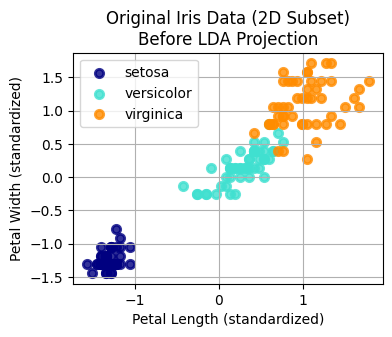

In [16]:
# Plotting the original data
plt.figure(figsize=(4, 3))
colors = ['navy', 'turquoise', 'darkorange']

for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_2d_scaled[y == i, 0],
                X_2d_scaled[y == i, 1],
                color=color, alpha=.8, lw=2, label=target_name)

plt.legend(loc='best', shadow=False)
plt.title('Original Iris Data (2D Subset)\nBefore LDA Projection')
plt.xlabel('Petal Length (standardized)')
plt.ylabel('Petal Width (standardized)')
plt.grid(True)
plt.show()


In [17]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [18]:
# Apply LDA to project 2D data to 1D
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda_1d = lda.fit_transform(X_2d_scaled, y)

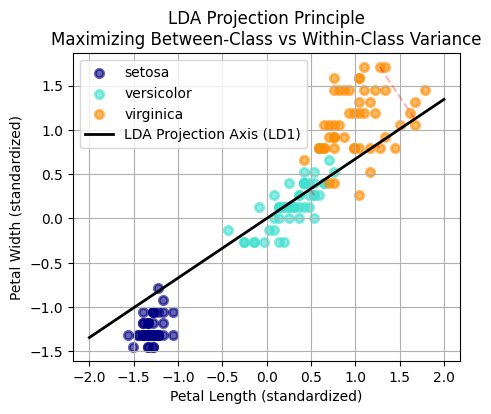

In [19]:
# Create a visualization showing the projection
plt.figure(figsize=(5, 4))

# Plot original data
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    plt.scatter(X_2d_scaled[y == i, 0],
                X_2d_scaled[y == i, 1],
                color=color, alpha=.6, lw=2, label=target_name)
# Plot the LDA projection direction (the discriminant vector)
lda_direction = lda.scalings_[:, 0]  # The first (and only) discriminant

# Create a line representing the LDA direction
x_plot = np.linspace(-2, 2, 100)
y_plot = (lda_direction[1] / lda_direction[0]) * x_plot

# Plot the LDA projection line
plt.plot(x_plot, y_plot, 'k-', linewidth=2, label='LDA Projection Axis (LD1)')
# Add projection lines for a few points
for i in [50, 75, 100, 125]:  # Sample points from different classes
    x_orig = X_2d_scaled[i, 0]
    y_orig = X_2d_scaled[i, 1]

    # Project point onto LDA direction
    t = (lda_direction[0]*x_orig + lda_direction[1]*y_orig) / (lda_direction[0]**2 + lda_direction[1]**2)
    x_proj = t * lda_direction[0]
    y_proj = t * lda_direction[1]

    # Draw projection line
    plt.plot([x_orig, x_proj], [y_orig, y_proj], 'r--', alpha=0.3)
plt.legend(loc='best')
plt.title('LDA Projection Principle\nMaximizing Between-Class vs Within-Class Variance')
plt.xlabel('Petal Length (standardized)')
plt.ylabel('Petal Width (standardized)')
plt.grid(True)
plt.axis('equal')
plt.show()

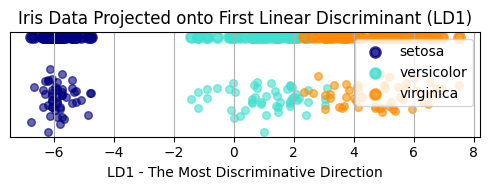

In [20]:
plt.figure(figsize=(5, 2))

# Create the 1D projection plot
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    class_data = X_lda_1d[y == i]
    plt.scatter(class_data, np.zeros_like(class_data) + 0.1,
                color=color, alpha=.8, lw=2, label=target_name, s=50)

# Add some jitter to see density better
y_jitter = np.random.normal(0, 0.02, size=len(X_lda_1d))
for color, i in zip(colors, [0, 1, 2]):
    class_data = X_lda_1d[y == i]
    jitter = y_jitter[y == i]
    plt.scatter(class_data, jitter, color=color, alpha=0.6, s=30)

plt.yticks([])
plt.title('Iris Data Projected onto First Linear Discriminant (LD1)')
plt.xlabel('LD1 - The Most Discriminative Direction')
plt.legend()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

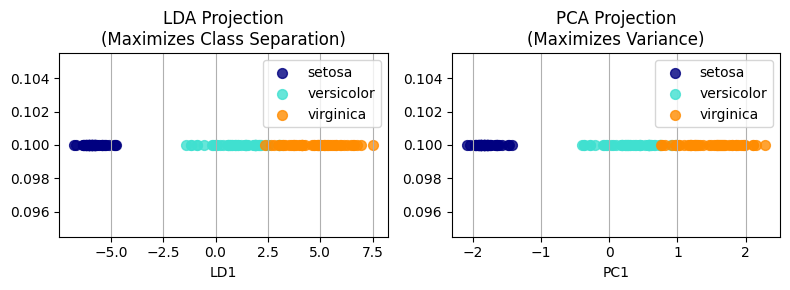

In [21]:
from sklearn.decomposition import PCA

# Apply PCA for comparison
pca = PCA(n_components=1)
X_pca_1d = pca.fit_transform(X_2d_scaled)

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))

# LDA projection
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    ax1.scatter(X_lda_1d[y == i], np.zeros_like(X_lda_1d[y == i]) + 0.1,
                color=color, alpha=.8, s=50, label=target_name)
ax1.set_title('LDA Projection\n(Maximizes Class Separation)')
ax1.set_xlabel('LD1')
ax1.grid(True, axis='x')
ax1.legend()

# PCA projection
for color, i, target_name in zip(colors, [0, 1, 2], target_names):
    ax2.scatter(X_pca_1d[y == i], np.zeros_like(X_pca_1d[y == i]) + 0.1,
                color=color, alpha=.8, s=50, label=target_name)
ax2.set_title('PCA Projection\n(Maximizes Variance)')
ax2.set_xlabel('PC1')
ax2.grid(True, axis='x')
ax2.legend()

plt.tight_layout()
plt.show()

Hyperparameter tuning for the Iris dataset

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Define the parameter grid
param_grid = {
    'solver': ['svd', 'lsqr', 'eigen'],
    'shrinkage': [None, 'auto', 0.2, 0.5, 0.8],
    'priors': [None, [0.33, 0.33, 0.33], [0.5, 0.25, 0.25]]  # Custom priors
}

# Create LDA classifier
lda = LinearDiscriminantAnalysis()

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(lda, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Display the best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Evaluate on test set
best_lda = grid_search.best_estimator_
y_pred_best = best_lda.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred_best)
print(f"Test Accuracy with Best Model: {test_accuracy:.3f}")

Best Parameters: {'priors': None, 'shrinkage': None, 'solver': 'svd'}
Best Cross-Validation Score: 0.975
Test Accuracy with Best Model: 1.000


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
60 fits failed out of a total of 225.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py", line 700, in fit
    raise NotImplementedErr

Category 6:

SVM

Test Accuracy (SVM - Linear Kernel): 0.97


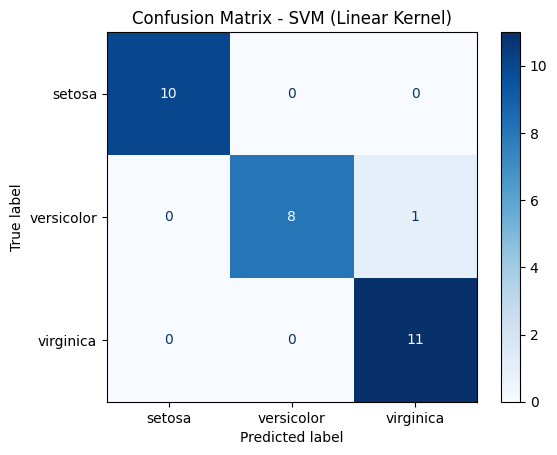

In [23]:
# Applying SVM for Classification (using same iris dataset)

from sklearn.svm import SVC

svm_clf = SVC(kernel='linear', random_state=42)

# Train the SVM model
svm_clf.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_svm = svm_clf.predict(X_test_scaled)

# Calculate and print accuracy
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Test Accuracy (SVM - Linear Kernel): {accuracy_svm:.2f}")

# Display the confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=target_names)
disp_svm.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - SVM (Linear Kernel)")
plt.show()

**Category 7:**

Neural Networks

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
✅ Dataset loaded from KaggleHub
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber op

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6287 - loss: 0.6188 - val_accuracy: 0.7911 - val_loss: 0.4241
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7855 - loss: 0.4591 - val_accuracy: 0.8000 - val_loss: 0.4147
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7799 - loss: 0.4458 - val_accuracy: 0.7991 - val_loss: 0.4132
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7939 - loss: 0.4355 - val_accuracy: 0.8036 - val_loss: 0.4122
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7905 - loss: 0.4386 - val_accuracy: 0.8053 - val_loss: 0.4084
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7962 - loss: 0.4455 - val_accuracy: 0.8062 - val_loss: 0.4097
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7944 - loss: 0.4378 - val_accuracy: 0.8053 - val_loss: 0.4093
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8088 - loss: 0.4121 - val_accuracy: 0.8044 - val_

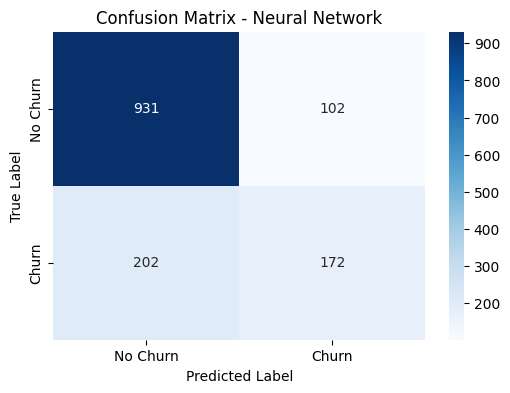

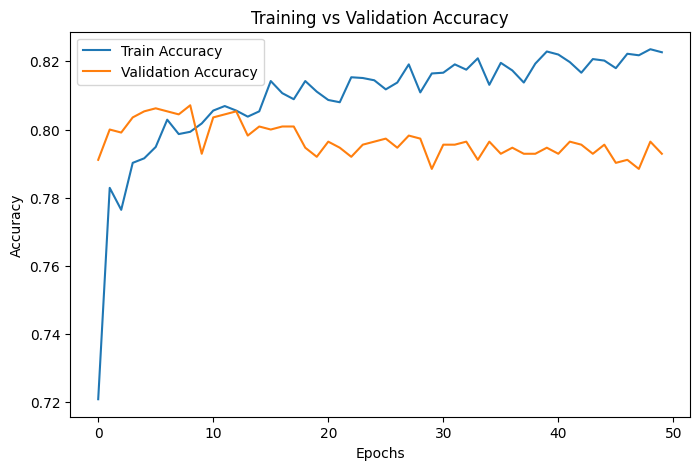

In [24]:
# Dataset: Telco Customer Churn
# Goal: Predict whether a customer will churn using a Neural Network

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout

# 2. Load Dataset
try:
    import kagglehub
    path = kagglehub.dataset_download("blastchar/telco-customer-churn")
    data = pd.read_csv(f"{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv")
    print("✅ Dataset loaded from KaggleHub")
except Exception as e:
    print("⚠️ KaggleHub download failed, loading local CSV if available.")
    data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(data.head())

# 3. Data Preprocessing
# Drop customerID (not predictive)
data = data.drop("customerID", axis=1)

# Convert TotalCharges to numeric (handle errors)
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data = data.dropna()

# Encode categorical variables
for col in data.select_dtypes(include=["object"]).columns:
    if col != "Churn":
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])

# Encode target variable
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

# Features and target
X = data.drop("Churn", axis=1)
y = data["Churn"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Build Neural Network
model = keras.Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")  # binary classification
])

# Compile model
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

# 5. Train Model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

# 6. Evaluate on Test Data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("✅ Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix - Neural Network")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# 8. Training Curves
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
✅ Dataset loaded from KaggleHub
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber op

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6438 - loss: 0.6262 - val_accuracy: 0.7902 - val_loss: 0.4256
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7822 - loss: 0.4608 - val_accuracy: 0.7973 - val_loss: 0.4140
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7831 - loss: 0.4422 - val_accuracy: 0.8062 - val_loss: 0.4105
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7900 - loss: 0.4371 - val_accuracy: 0.8036 - val_loss: 0.4121
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7947 - loss: 0.4364 - val_accuracy: 0.8080 - val_loss: 0.4101
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7834 - loss: 0.4589 - val_accuracy: 0.8018 - val_loss: 0.4102
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8068 - loss: 0.4241 - val_accuracy: 0.8080 - val_loss: 0.4087
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8052 - loss: 0.4199 - val_accuracy: 0.8107 - val_

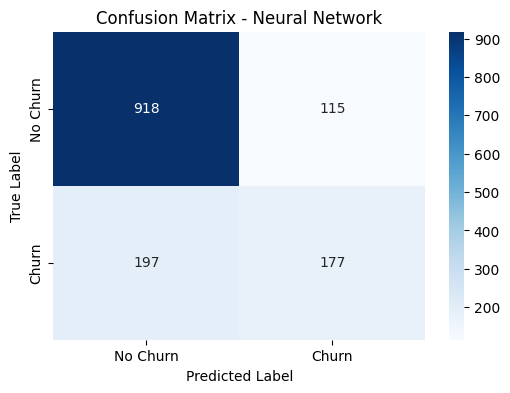

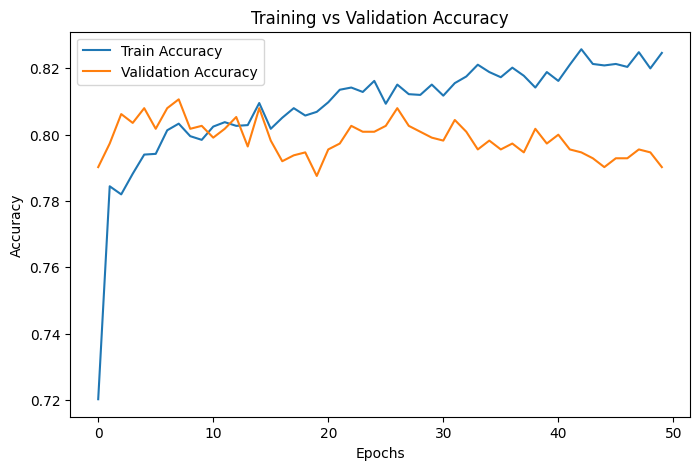

In [25]:
# Telco Customer Churn Prediction with Neural Network
# Includes explicit Hyperparameters

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout

# ---------------------------------------------------
# 🔑 Define Key Hyperparameters
# ---------------------------------------------------
HIDDEN_UNITS_1 = 64          # Number of neurons in first hidden layer
HIDDEN_UNITS_2 = 32          # Number of neurons in second hidden layer
DROPOUT_RATE = 0.3           # Dropout to prevent overfitting
LEARNING_RATE = 0.001        # Adam learning rate
EPOCHS = 50                  # Number of passes through training data
BATCH_SIZE = 32              # Mini-batch size
ACTIVATION_HIDDEN = "relu"   # Activation for hidden layers
ACTIVATION_OUTPUT = "sigmoid" # Binary classification
LOSS_FN = "binary_crossentropy"
OPTIMIZER = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
# ---------------------------------------------------

# 2. Load Dataset
try:
    import kagglehub
    path = kagglehub.dataset_download("blastchar/telco-customer-churn")
    data = pd.read_csv(f"{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv")
    print("✅ Dataset loaded from KaggleHub")
except Exception as e:
    print("⚠️ KaggleHub download failed, loading local CSV if available.")
    data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(data.head())

# 3. Data Preprocessing
data = data.drop("customerID", axis=1)
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data = data.dropna()

for col in data.select_dtypes(include=["object"]).columns:
    if col != "Churn":
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])

data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

X = data.drop("Churn", axis=1)
y = data["Churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Build Neural Network (using hyperparameters)
model = keras.Sequential([
    Dense(HIDDEN_UNITS_1, activation=ACTIVATION_HIDDEN, input_shape=(X_train.shape[1],)),
    Dropout(DROPOUT_RATE),
    Dense(HIDDEN_UNITS_2, activation=ACTIVATION_HIDDEN),
    Dropout(DROPOUT_RATE),
    Dense(1, activation=ACTIVATION_OUTPUT)
])

# Compile model with chosen hyperparameters
model.compile(optimizer=OPTIMIZER,
              loss=LOSS_FN,
              metrics=["accuracy"])

# 5. Train Model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# 6. Evaluate on Test Data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("✅ Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 7. Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix - Neural Network")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# 8. Training Curves
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
✅ Dataset loaded from KaggleHub
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5744 - loss: 0.8731 - val_accuracy: 0.7733 - val_loss: 0.6156 - learning_rate: 0.0010
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7146 - loss: 0.6483 - val_accuracy: 0.7964 - val_loss: 0.5485 - learning_rate: 0.0010
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7583 - loss: 0.5814 - val_accuracy: 0.8027 - val_loss: 0.5197 - learning_rate: 0.0010
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7674 - loss: 0.5649 - val_accuracy: 0.7991 - val_loss: 0.5096 - learning_rate: 0.0010
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7797 - loss: 0.5375 - val_accuracy: 0.8036 - val_loss: 0.4995 - learning_rate: 0.0010
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7799 - loss: 0.5422 - val_accuracy: 0.8062 - val_loss: 0.4971 - learning_rate: 0.0010
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7729 - loss: 0.5434 - val_a

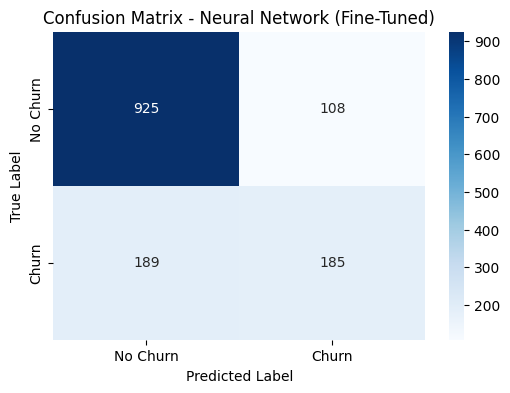

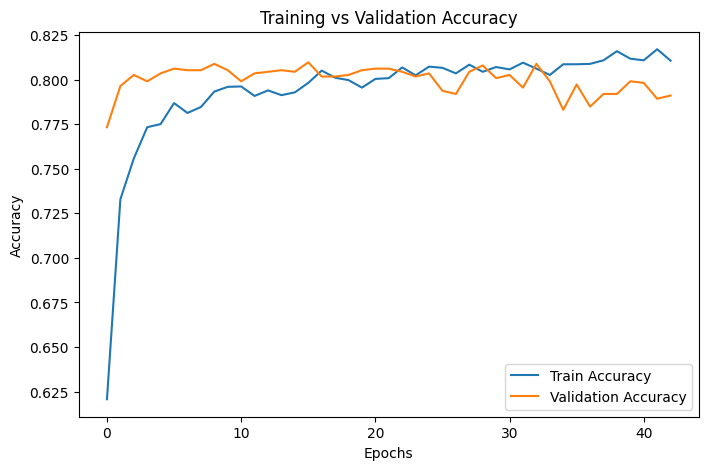

In [26]:
# Telco Customer Churn Prediction with Fine-Tuned Neural Network

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ---------------------------------------------------
# 🔑 Hyperparameters (Tuned)
# ---------------------------------------------------
HIDDEN_UNITS_1 = 64
HIDDEN_UNITS_2 = 32
HIDDEN_UNITS_3 = 16
DROPOUT_RATE = 0.25
LEARNING_RATE = 0.001
EPOCHS = 100               # allow more, early stopping will cut off
BATCH_SIZE = 32
ACTIVATION_HIDDEN = "relu"
ACTIVATION_OUTPUT = "sigmoid"
LOSS_FN = "binary_crossentropy"
OPTIMIZER = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
# ---------------------------------------------------

# 2. Load Dataset
try:
    import kagglehub
    path = kagglehub.dataset_download("blastchar/telco-customer-churn")
    data = pd.read_csv(f"{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv")
    print("✅ Dataset loaded from KaggleHub")
except Exception as e:
    print("⚠️ KaggleHub download failed, loading local CSV if available.")
    data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 3. Data Preprocessing
data = data.drop("customerID", axis=1)
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data = data.dropna()

for col in data.select_dtypes(include=["object"]).columns:
    if col != "Churn":
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])

data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

X = data.drop("Churn", axis=1)
y = data["Churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Build Fine-Tuned Neural Network
model = keras.Sequential([
    Dense(HIDDEN_UNITS_1, activation=ACTIVATION_HIDDEN,
          kernel_regularizer=regularizers.l2(0.001), input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(DROPOUT_RATE),

    Dense(HIDDEN_UNITS_2, activation=ACTIVATION_HIDDEN, kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(DROPOUT_RATE),

    Dense(HIDDEN_UNITS_3, activation=ACTIVATION_HIDDEN, kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Dropout(DROPOUT_RATE),

    Dense(1, activation=ACTIVATION_OUTPUT)
])

# Compile model
model.compile(optimizer=OPTIMIZER, loss=LOSS_FN, metrics=["accuracy"])

# 5. Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)

# 6. Train Model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[early_stop, reduce_lr]
)

# 7. Evaluate on Test Data
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("✅ Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Confusion Matrix - Neural Network (Fine-Tuned)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# 9. Training Curves
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**FOOTNOTE**

Advantage for using AI: Needing less time to collect information and to evaluate it for accuracy as compared to using bibliographical research.